In [3]:
import kagglehub
path = kagglehub.dataset_download("blastchar/telco-customer-churn")
# IBM HR : "pavansubhasht/ibm-hr-analytics-attrition-dataset"

In [4]:
import glob
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

path = glob.glob("/kaggle/input/**/*Telco*Churn*.csv", recursive=True)[0]
df = pd.read_csv(path)
print(path, df.shape)
df.head()

/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# TotalCharges est en texte, avec des espaces vides pour les clients à tenure = 0
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.loc[df["tenure"] == 0, "TotalCharges"] = 0.0   # nouveaux clients : rien facturé encore

# SeniorCitizen est codé 0/1 : on le traite comme catégorielle
df["SeniorCitizen"] = df["SeniorCitizen"].map({0: "No", 1: "Yes"})

# Cible binaire : 1 = client parti
df["Churn"] = (df["Churn"] == "Yes").astype(int)

df = df.drop(columns="customerID")   # identifiant, inutile pour modéliser
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   object 
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [7]:
print("Valeurs manquantes :\n", df.isna().sum()[df.isna().sum() > 0], "\n")
print("Doublons :", df.duplicated().sum())

# Proportion des classes
counts = df["Churn"].value_counts()
print(counts, "\n", df["Churn"].value_counts(normalize=True).round(3))

fig = px.pie(values=counts.values, names=["Reste (0)", "Part (1)"], hole=0.4,
             title="Répartition de la cible")
fig.show()

Valeurs manquantes :
 Series([], dtype: int64) 

Doublons : 22
Churn
0    5174
1    1869
Name: count, dtype: int64 
 Churn
0    0.735
1    0.265
Name: proportion, dtype: float64


In [8]:
num_cols = df.select_dtypes(include="number").columns.drop("Churn").tolist()
cat_cols = df.select_dtypes(exclude="number").columns.tolist()

display(df[num_cols].describe().T)
display(df[cat_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75
TotalCharges,7043.0,2279.734304,2266.794470,0.00,398.55,1394.55,3786.60,8684.80


,count,unique,top,freq
gender,7043,2,Male,3555
SeniorCitizen,7043,2,No,5901
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


In [9]:
for col in num_cols:
    fig = px.histogram(df, x=col, color=df["Churn"].astype(str), barmode="overlay",
                       opacity=0.65, marginal="box", nbins=40,
                       labels={"color": "Churn"}, title=f"Distribution de {col} selon Churn")
    fig.show()

In [10]:
overall = df["Churn"].mean()

for col in cat_cols:
    rates = df.groupby(col)["Churn"].mean().reset_index()
    fig = px.bar(rates, x=col, y="Churn", text=rates["Churn"].map("{:.1%}".format),
                 title=f"Taux de churn par {col}")
    fig.add_hline(y=overall, line_dash="dash", annotation_text=f"Moyenne {overall:.1%}")
    fig.show()

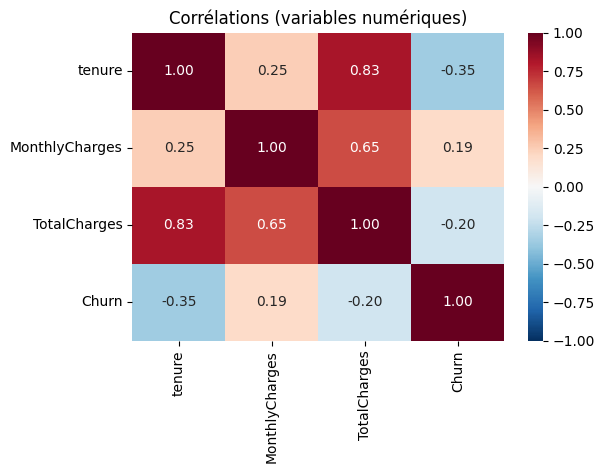

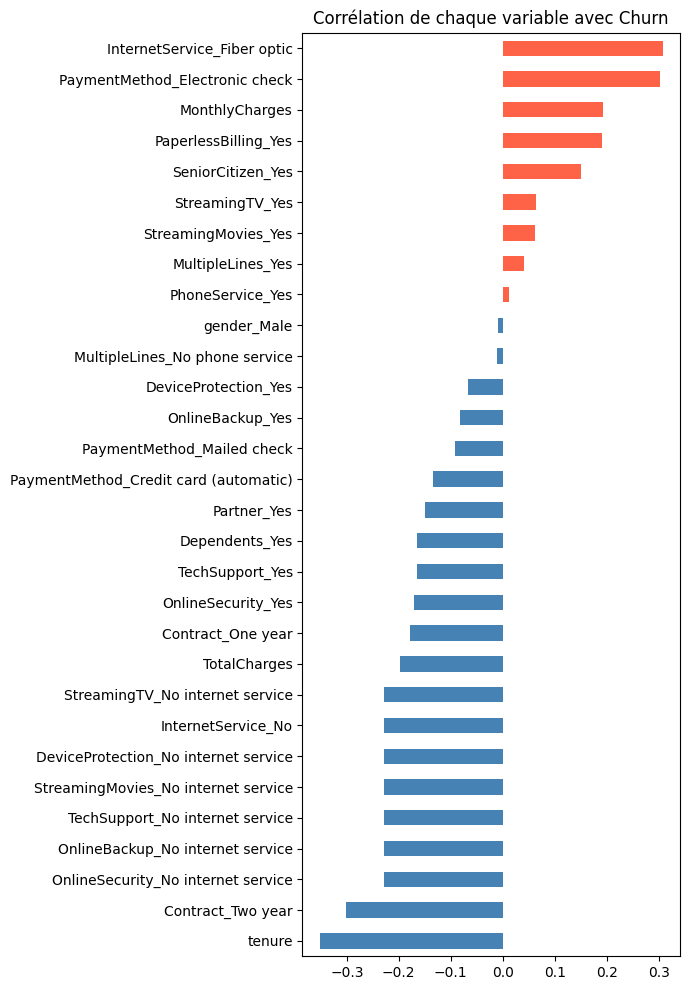

In [11]:
# (a) Corrélation entre variables numériques et la cible
plt.figure(figsize=(6, 4))
sns.heatmap(df[num_cols + ["Churn"]].corr(), annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1)
plt.title("Corrélations (variables numériques)")
plt.show()

# (b) Corrélation de TOUTES les variables (encodées) avec Churn
encoded = pd.get_dummies(df, drop_first=True).astype(float)
corr_target = encoded.corr()["Churn"].drop("Churn").sort_values()

plt.figure(figsize=(7, 10))
corr_target.plot(kind="barh", color=np.where(corr_target > 0, "tomato", "steelblue"))
plt.title("Corrélation de chaque variable avec Churn")
plt.tight_layout()
plt.show()

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Paramètres modifiables
TEST_SIZE = 0.2
SEED = 42

X = df.drop(columns="Churn")
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y)

preprocessor = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("sc", StandardScaler())]), num_cols),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("oh", OneHotEncoder(drop="if_binary", handle_unknown="ignore",
                                           sparse_output=False))]), cat_cols),
], verbose_feature_names_out=False)
preprocessor.set_output(transform="pandas")

# Ajusté sur le train uniquement (pas de fuite de données)
Xtr = preprocessor.fit_transform(X_train)
Xte = preprocessor.transform(X_test)

print("Train :", Xtr.shape, f"| churn = {y_train.mean():.1%}")
print("Test  :", Xte.shape, f"| churn = {y_test.mean():.1%}")
Xtr.head()

Train : (5634, 40) | churn = 26.5%
Test  : (1409, 40) | churn = 26.5%


,tenure,MonthlyCharges,TotalCharges,gender_Male,SeniorCitizen_Yes,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No,MultipleLines_No phone service,...,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3738,0.102371,-0.521976,-0.262257,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3151,-0.711743,0.337478,-0.503635,1.0,0.0,1.0,1.0,1.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4860,-0.793155,-0.809013,-0.749883,1.0,0.0,1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3867,-0.263980,0.284384,-0.172722,0.0,0.0,1.0,0.0,1.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0
3810,-1.281624,-0.676279,-0.989374,1.0,0.0,1.0,1.0,1.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [13]:
import time
from sklearn.base import clone
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, ParameterGrid
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# ---------- Paramètres modifiables ----------
SELECTED = ["Régression logistique", "Arbre de décision", "KNN", "Random Forest", "XGBoost"]
N_ITER = 20          # nombre de combinaisons testées par modèle
CV_FOLDS = 5
SCORING = "roc_auc"  # ou "average_precision", "f1"
# --------------------------------------------

# Gestion du déséquilibre (~26 % de churn)
spw = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    "Régression logistique": (
        LogisticRegression(max_iter=2000, class_weight="balanced"),
        {"clf__C": [0.001, 0.01, 0.1, 1, 10, 100]},
    ),
    "Arbre de décision": (
        DecisionTreeClassifier(class_weight="balanced", random_state=SEED),
        {"clf__max_depth": [3, 4, 5, 7, 10, None],
         "clf__min_samples_leaf": [1, 5, 10, 20, 50],
         "clf__criterion": ["gini", "entropy"]},
    ),
    "KNN": (
        KNeighborsClassifier(),
        {"clf__n_neighbors": [3, 5, 7, 11, 15, 21, 31],
         "clf__weights": ["uniform", "distance"],
         "clf__p": [1, 2]},
    ),
    "Random Forest": (
        RandomForestClassifier(class_weight="balanced", random_state=SEED, n_jobs=-1),
        {"clf__n_estimators": [100, 200, 300],
         "clf__max_depth": [5, 8, 12, None],
         "clf__min_samples_leaf": [1, 3, 5, 10],
         "clf__max_features": ["sqrt", 0.5]},
    ),
    "XGBoost": (
        XGBClassifier(scale_pos_weight=spw, eval_metric="logloss",
                      random_state=SEED, n_jobs=-1),
        {"clf__n_estimators": [100, 200, 300],
         "clf__max_depth": [3, 4, 5, 6],
         "clf__learning_rate": [0.03, 0.05, 0.1, 0.2],
         "clf__subsample": [0.7, 0.85, 1.0],
         "clf__colsample_bytree": [0.6, 0.8, 1.0]},
    ),
}

In [14]:
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)

best_models, best_params, cv_scores, fit_times = {}, {}, {}, {}

for name in SELECTED:
    estimator, grid = models[name]
    # Pipeline = prétraitement + modèle (le prétraitement est refait à chaque pli de CV)
    prep = clone(preprocessor).set_output(transform="pandas")
    pipe = Pipeline([("prep", prep), ("clf", estimator)])

    n_iter = min(N_ITER, len(ParameterGrid(grid)))
    search = RandomizedSearchCV(pipe, grid, n_iter=n_iter, scoring=SCORING,
                                cv=cv, random_state=SEED, n_jobs=-1, refit=True)
    t0 = time.time()
    search.fit(X_train, y_train)
    fit_times[name] = time.time() - t0

    best_models[name] = search.best_estimator_
    best_params[name] = {k.replace("clf__", ""): v for k, v in search.best_params_.items()}
    cv_scores[name] = search.best_score_
    print(f"✔ {name:<22} CV {SCORING} = {search.best_score_:.4f}  ({fit_times[name]:.0f}s)")
    print("   ", best_params[name])

✔ Régression logistique  CV roc_auc = 0.8462  (3s)
    {'C': 10}
✔ Arbre de décision      CV roc_auc = 0.8300  (5s)
    {'min_samples_leaf': 1, 'max_depth': 5, 'criterion': 'entropy'}
✔ KNN                    CV roc_auc = 0.8337  (9s)
    {'weights': 'uniform', 'p': 1, 'n_neighbors': 31}
✔ Random Forest          CV roc_auc = 0.8479  (48s)
    {'n_estimators': 100, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_depth': 8}
✔ XGBoost                CV roc_auc = 0.8496  (13s)
    {'subsample': 0.7, 'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.03, 'colsample_bytree': 0.8}


In [15]:
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             precision_score, recall_score, f1_score)

THRESHOLD = 0.5   # le curseur de seuil viendra à l'étape Évaluation
probas = {}       # gardé pour les courbes ROC / PR de l'étape suivante
rows = []

for name, model in best_models.items():
    p_test = model.predict_proba(X_test)[:, 1]
    p_train = model.predict_proba(X_train)[:, 1]
    probas[name] = p_test
    pred = (p_test >= THRESHOLD).astype(int)
    rows.append({
        "Modèle": name,
        f"AUC CV ({CV_FOLDS} plis)": cv_scores[name],
        "AUC test": roc_auc_score(y_test, p_test),
        "PR-AUC": average_precision_score(y_test, p_test),
        "Précision": precision_score(y_test, pred),
        "Rappel": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "Écart AUC train-test": roc_auc_score(y_train, p_train) - roc_auc_score(y_test, p_test),
        "Temps (s)": fit_times[name],
    })

results = pd.DataFrame(rows).set_index("Modèle").sort_values("AUC test", ascending=False)
results.style.format("{:.3f}").background_gradient(
    cmap="Greens", subset=["AUC test", "PR-AUC", "Précision", "Rappel", "F1"]
).background_gradient(cmap="Reds", subset=["Écart AUC train-test"])

,AUC CV (5 plis),AUC test,PR-AUC,Précision,Rappel,F1,Écart AUC train-test,Temps (s)
Modèle,,,,,,,,
XGBoost,0.850,0.847,0.662,0.524,0.807,0.636,0.025,12.641
Random Forest,0.848,0.844,0.658,0.527,0.789,0.632,0.041,47.823
Régression logistique,0.846,0.841,0.627,0.504,0.783,0.614,0.009,3.333
Arbre de décision,0.830,0.837,0.625,0.525,0.749,0.617,0.015,4.594
KNN,0.834,0.826,0.612,0.582,0.570,0.576,0.031,9.384


In [16]:
plot_df = results[["AUC test", "PR-AUC", "Précision", "Rappel", "F1"]].reset_index().melt(
    id_vars="Modèle", var_name="Métrique", value_name="Valeur")
fig = px.bar(plot_df, x="Modèle", y="Valeur", color="Métrique", barmode="group",
             title=f"Comparaison des modèles (seuil = {THRESHOLD})")
fig.show()

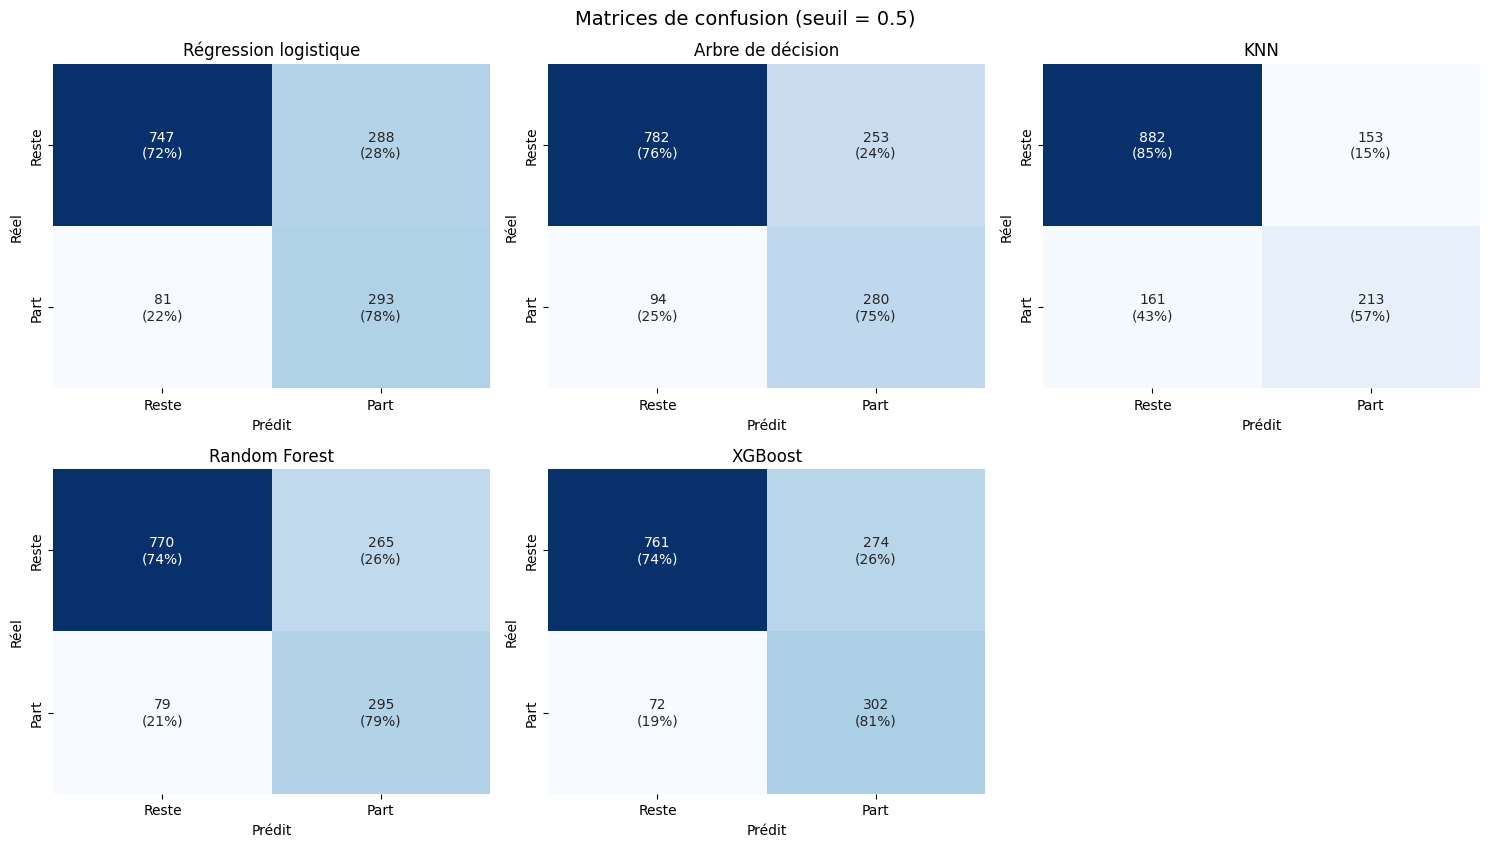

In [17]:
from sklearn.metrics import confusion_matrix

THRESHOLD = 0.5   # à modifier pour voir l'effet sur chaque matrice

names = list(best_models.keys())
n = len(names)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.3 * nrows))
axes = np.array(axes).ravel()

for ax, name in zip(axes, names):
    pred = (probas[name] >= THRESHOLD).astype(int)
    cm = confusion_matrix(y_test, pred)
    cm_pct = cm / cm.sum(axis=1, keepdims=True)          # % par classe réelle
    labels = np.array([[f"{cm[i, j]}\n({cm_pct[i, j]:.0%})" for j in range(2)] for i in range(2)])

    sns.heatmap(cm, annot=labels, fmt="", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Reste", "Part"], yticklabels=["Reste", "Part"])
    ax.set_title(name)
    ax.set_xlabel("Prédit")
    ax.set_ylabel("Réel")

for ax in axes[n:]:        # masquer les cases vides
    ax.axis("off")

fig.suptitle(f"Matrices de confusion (seuil = {THRESHOLD})", fontsize=14)
plt.tight_layout()
plt.show()

In [18]:
import ipywidgets as widgets
from IPython.display import display, clear_output

model_dd = widgets.Dropdown(options=names, description="Modèle :")
thr_sl = widgets.FloatSlider(value=0.5, min=0.05, max=0.95, step=0.01,
                             description="Seuil :", continuous_update=False,
                             layout=widgets.Layout(width="450px"))
out = widgets.Output()

def update(_=None):
    with out:
        clear_output(wait=True)
        name, thr = model_dd.value, thr_sl.value
        pred = (probas[name] >= thr).astype(int)
        cm = confusion_matrix(y_test, pred)
        tn, fp, fn, tp = cm.ravel()
        precision = tp / (tp + fp) if (tp + fp) else 0
        recall = tp / (tp + fn)

        fig, ax = plt.subplots(figsize=(4.5, 3.8))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                    xticklabels=["Reste", "Part"], yticklabels=["Reste", "Part"])
        ax.set_xlabel("Prédit"); ax.set_ylabel("Réel")
        ax.set_title(f"{name} – seuil {thr:.2f}")
        plt.show()
        print(f"Rappel    : {recall:.1%}  ({tp} départs détectés sur {tp + fn})")
        print(f"Précision : {precision:.1%}  ({fp} fausses alertes)")
        print(f"Départs manqués : {fn}")

model_dd.observe(update, names="value")
thr_sl.observe(update, names="value")
display(widgets.VBox([model_dd, thr_sl, out]))
update()

In [26]:
def add_features(d):
    d = d.copy()
    services = ["PhoneService", "MultipleLines", "OnlineSecurity", "OnlineBackup",
                "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]
    protection = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport"]
    d["nb_services"] = (d[services] == "Yes").sum(axis=1)
    d["nb_protection"] = (d[protection] == "Yes").sum(axis=1)
    d["avg_monthly_paid"] = d["TotalCharges"] / d["tenure"].clip(lower=1)
    d["charge_gap"] = d["MonthlyCharges"] - d["avg_monthly_paid"]   # hausse récente de tarif ?
    d["auto_pay"] = np.where(d["PaymentMethod"].str.contains("automatic"), "Yes", "No")
    d["new_customer"] = np.where(d["tenure"] <= 12, "Yes", "No")
    return d

X_train_fe, X_test_fe = add_features(X_train), add_features(X_test)

# Comparaison rapide en validation croisée (régression logistique, cheap)
def make_prep(Xdf):
    nc = Xdf.select_dtypes(include="number").columns.tolist()
    cc = Xdf.select_dtypes(exclude="number").columns.tolist()
    pre = ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]), nc),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                          ("oh", OneHotEncoder(drop="if_binary", handle_unknown="ignore",
                                               sparse_output=False))]), cc),
    ], verbose_feature_names_out=False)
    pre.set_output(transform="pandas")
    return pre, nc, cc

from sklearn.model_selection import cross_val_score
for label, Xd in [("Avant", X_train), ("Après", X_train_fe)]:
    pre, _, _ = make_prep(Xd)
    pipe = Pipeline([("prep", pre), ("clf", LogisticRegression(C=1, max_iter=5000,
                                                               class_weight="balanced"))])
    s = cross_val_score(pipe, Xd, y_train, cv=cv, scoring="roc_auc")
    print(f"{label} : AUC CV = {s.mean():.4f} ± {s.std():.4f}")

Avant : AUC CV = 0.8460 ± 0.0124
Après : AUC CV = 0.8458 ± 0.0115


# **Explainable AI**

In [27]:
import warnings; warnings.filterwarnings("ignore")
import shap, lime, lime.lime_tabular
from sklearn.inspection import permutation_importance
from sklearn.tree import DecisionTreeClassifier

# ---------- Paramètres modifiables ----------
MODEL_NAME = "XGBoost" if "XGBoost" in best_models else results.index[0]
THRESHOLD = 0.5      # seuil de décision (utilise ton seuil optimal si tu en as un)
# --------------------------------------------
assert MODEL_NAME != "KNN", "SHAP n'est pas adapté à KNN (trop lent) : choisis un autre modèle."

model = best_models[MODEL_NAME]
prep, clf = model.named_steps["prep"], model.named_steps["clf"]
Xtr_t, Xte_t = prep.transform(X_train), prep.transform(X_test)
feat_names = list(Xte_t.columns)
p_test = model.predict_proba(X_test)[:, 1]
print(MODEL_NAME, "| colonnes après encodage :", len(feat_names))

XGBoost | colonnes après encodage : 40


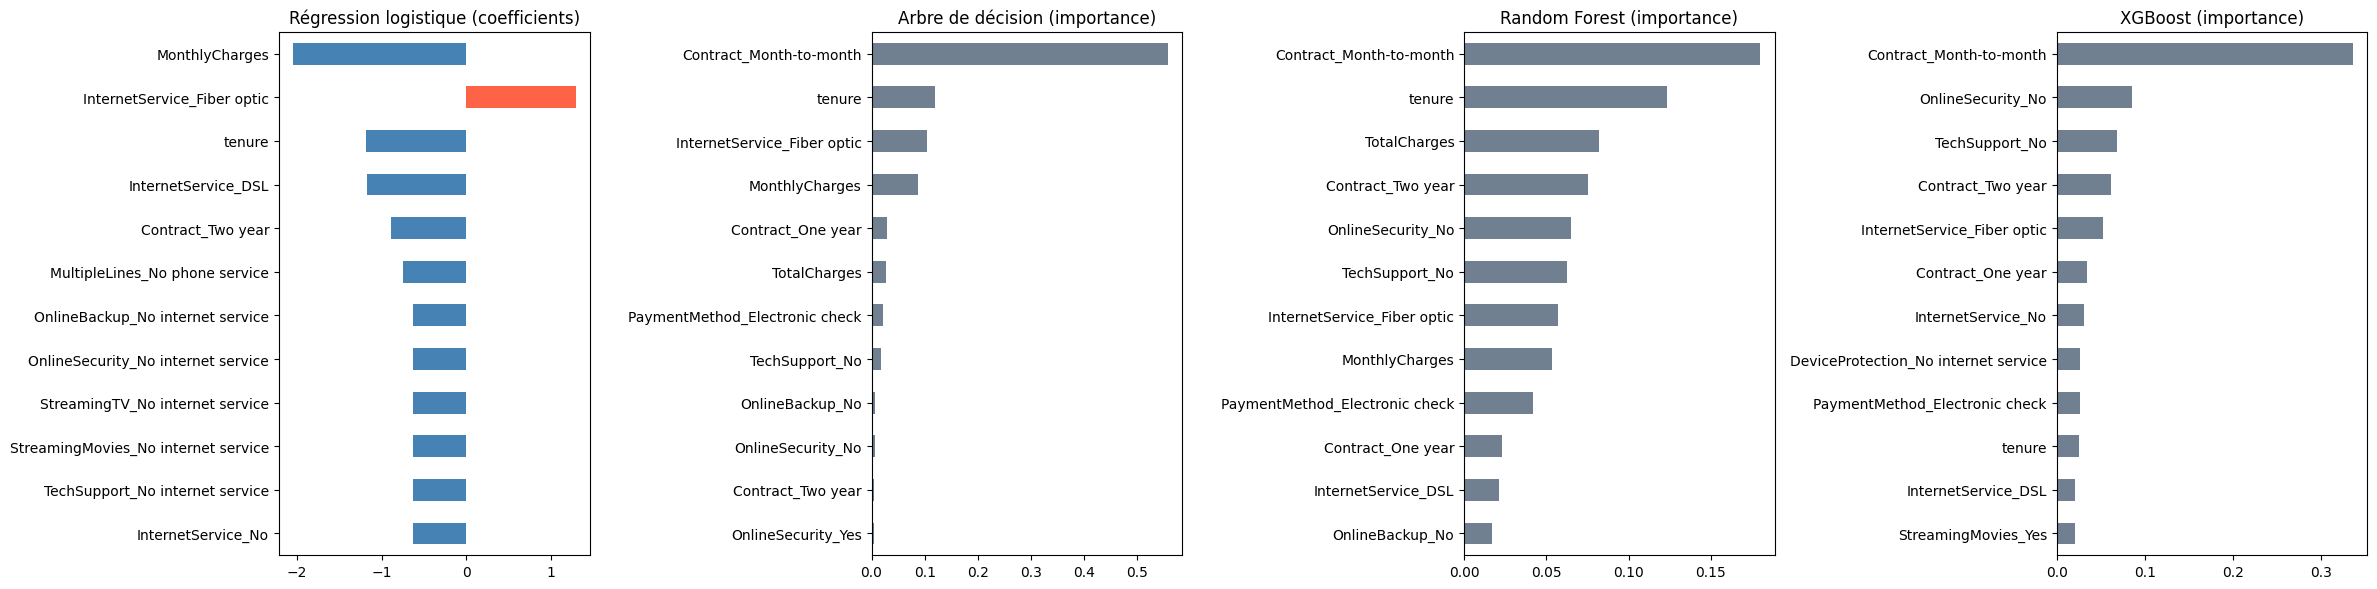

In [28]:
def native_importance(m):
    c = m.named_steps["clf"]
    names = m.named_steps["prep"].get_feature_names_out()
    if hasattr(c, "coef_"):                    # régression logistique : coefficients signés
        return pd.Series(c.coef_.ravel(), index=names)
    if hasattr(c, "feature_importances_"):     # arbre, forêt, XGBoost : importance par impureté/gain
        return pd.Series(c.feature_importances_, index=names)
    return None                                # KNN : pas d'importance native

avail = {n: native_importance(m) for n, m in best_models.items()}
avail = {n: s for n, s in avail.items() if s is not None}

fig, axes = plt.subplots(1, len(avail), figsize=(6 * len(avail), 6))
for ax, (n, s) in zip(np.atleast_1d(axes), avail.items()):
    top = s.reindex(s.abs().sort_values(ascending=False).head(12).index)[::-1]
    signed = (s < 0).any()
    colors = np.where(top > 0, "tomato", "steelblue") if signed else "slategray"
    top.plot(kind="barh", ax=ax, color=colors)
    ax.set_title(n + (" (coefficients)" if signed else " (importance)"))
plt.tight_layout(); plt.show()

In [29]:
perm = {}
for n, m in best_models.items():
    r = permutation_importance(m, X_test, y_test, scoring="roc_auc",
                               n_repeats=10, random_state=SEED, n_jobs=-1)
    perm[n] = pd.Series(r.importances_mean, index=X_test.columns)

perm_df = pd.DataFrame(perm)
perm_df.index.name = "Variable"
top_vars = perm_df.mean(axis=1).sort_values(ascending=False).head(12).index

plot = perm_df.loc[top_vars].reset_index().melt(
    id_vars="Variable", var_name="Modèle", value_name="Baisse d'AUC")
fig = px.bar(plot, x="Baisse d'AUC", y="Variable", color="Modèle", barmode="group",
             orientation="h", height=600,
             title="Importance par permutation (baisse d'AUC quand on mélange la variable)")
fig.update_yaxes(autorange="reversed")
fig.show()